In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,roc_auc_score,roc_curve,auc
from pandas.tseries.offsets import MonthEnd
from sklearn.model_selection import TimeSeriesSplit
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier

In [2]:
df = pd.read_csv('Hotel_Reservations.csv')

## EDA And PreProcessing

In [4]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [6]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

There is no missing value in any column

In [8]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


<Axes: >

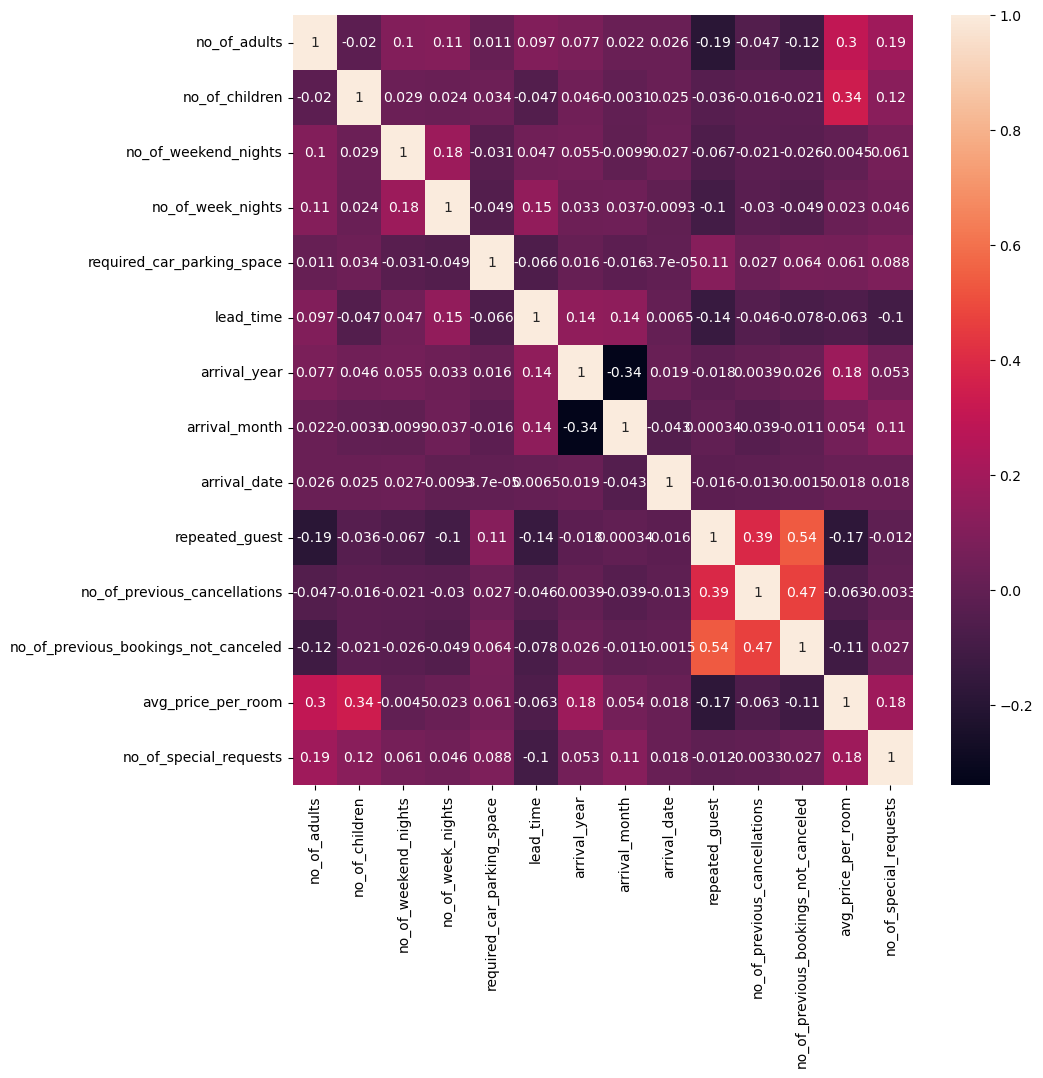

In [9]:
co = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(co, annot = True)

In [10]:
df['no_of_adults'].value_counts()

no_of_adults
2    26108
1     7695
3     2317
0      139
4       16
Name: count, dtype: int64

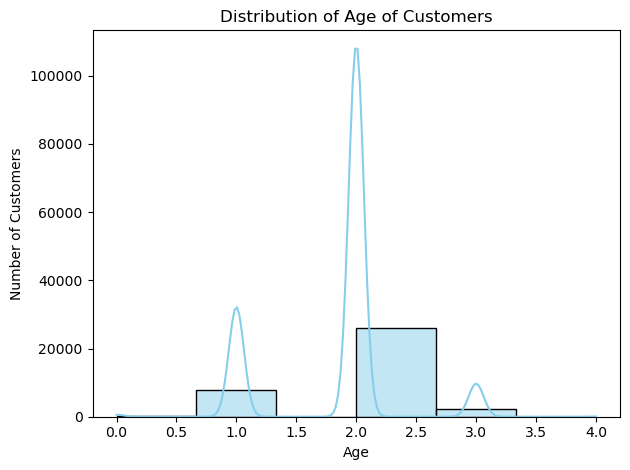

In [11]:
sns.histplot(data=df, x='no_of_adults', bins=6, kde=True, color='skyblue')
plt.title('Distribution of Age of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

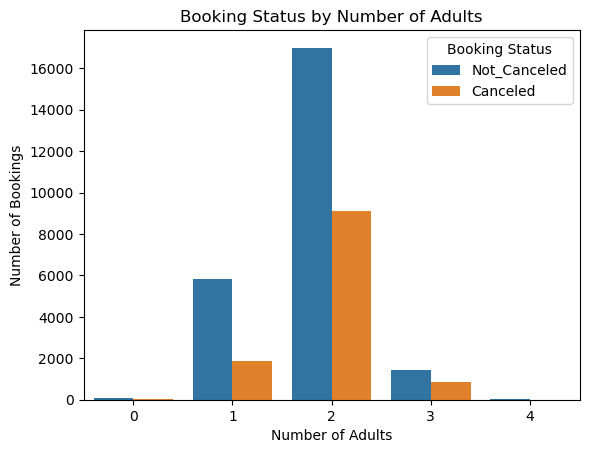

In [12]:
sns.countplot(x='no_of_adults', data=df, hue='booking_status')
plt.title('Booking Status by Number of Adults') 
plt.xlabel('Number of Adults')                 
plt.ylabel('Number of Bookings')                
plt.legend(title='Booking Status')              
plt.show()

In [13]:
df['no_of_children'].value_counts()

no_of_children
0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: count, dtype: int64

In [14]:
df = df[df['no_of_children'] <= 3]

In [15]:
df['no_of_children'].value_counts()

no_of_children
0    33577
1     1618
2     1058
3       19
Name: count, dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36272 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36272 non-null  object 
 1   no_of_adults                          36272 non-null  int64  
 2   no_of_children                        36272 non-null  int64  
 3   no_of_weekend_nights                  36272 non-null  int64  
 4   no_of_week_nights                     36272 non-null  int64  
 5   type_of_meal_plan                     36272 non-null  object 
 6   required_car_parking_space            36272 non-null  int64  
 7   room_type_reserved                    36272 non-null  object 
 8   lead_time                             36272 non-null  int64  
 9   arrival_year                          36272 non-null  int64  
 10  arrival_month                         36272 non-null  int64  
 11  arrival_date        

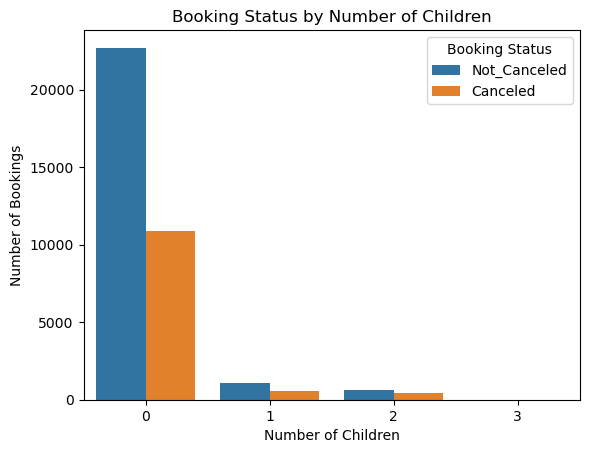

In [17]:
sns.countplot(x='no_of_children', data=df, hue='booking_status')
plt.title('Booking Status by Number of Children')  
plt.xlabel('Number of Children')                  
plt.ylabel('Number of Bookings')                  
plt.legend(title='Booking Status')
plt.show()

In [18]:
df['no_of_weekend_nights'].value_counts()

no_of_weekend_nights
0    16871
1     9995
2     9069
3      153
4      129
5       34
6       20
7        1
Name: count, dtype: int64

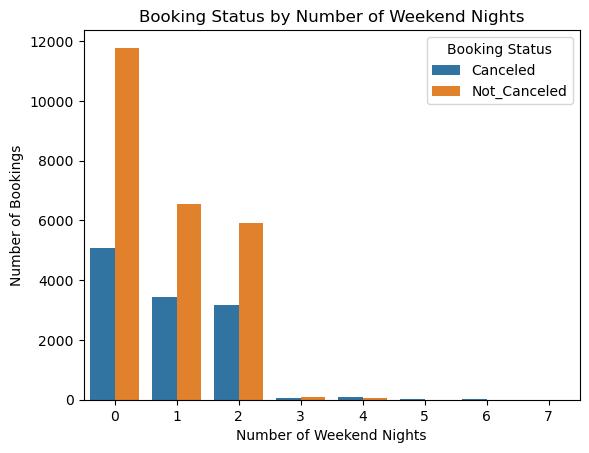

In [19]:
sns.countplot(x='no_of_weekend_nights', data=df, hue='booking_status')
plt.title('Booking Status by Number of Weekend Nights')  
plt.xlabel('Number of Weekend Nights')                   
plt.ylabel('Number of Bookings')                         
plt.legend(title='Booking Status')
plt.show()

1. The chart shows the relationship between booking status and the number of weekend nights.
2. Most bookings occur with zero or one weekend night.
3. Cancellations are higher when there are no weekend nights compared to other categories.
4. As the number of weekend nights increases, both canceled and not-canceled bookings decrease sharply.
5. This indicates that shorter stays (fewer weekend nights) are more common and slightly more likely to be canceled.

In [20]:
count = df[(df['no_of_weekend_nights'] == 4) & (df['booking_status'] == 'Canceled')].shape[0]

In [21]:
print(count)

83


In [22]:
count = df[(df['no_of_weekend_nights'] == 5) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

29


In [23]:
count = df[(df['no_of_weekend_nights'] == 6) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

16


In [24]:
df['no_of_week_nights'].value_counts()

no_of_week_nights
2     11443
1      9487
3      7839
4      2990
0      2387
5      1613
6       189
7       113
10       62
8        62
9        34
11       17
15       10
12        9
14        7
13        5
17        3
16        2
Name: count, dtype: int64

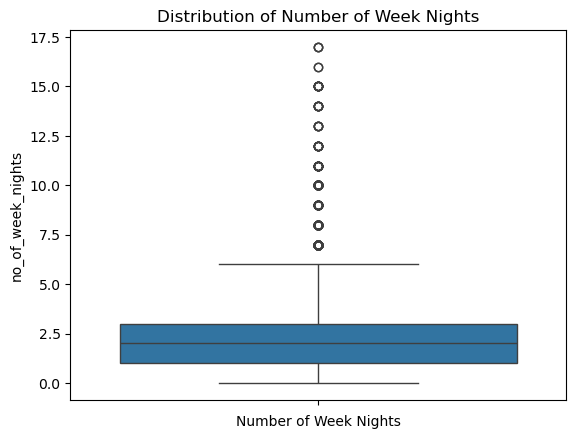

In [25]:
sns.boxplot(y=df['no_of_week_nights'])
plt.title('Distribution of Number of Week Nights')
plt.xlabel('Number of Week Nights')
plt.show()

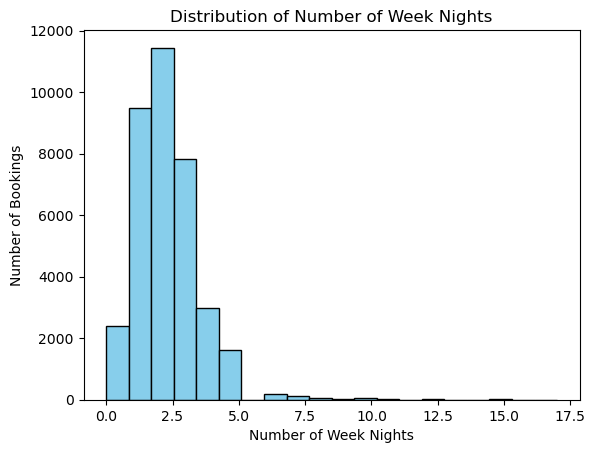

In [26]:
plt.hist(df['no_of_week_nights'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Number of Week Nights')
plt.xlabel('Number of Week Nights')
plt.ylabel('Number of Bookings')
plt.show()

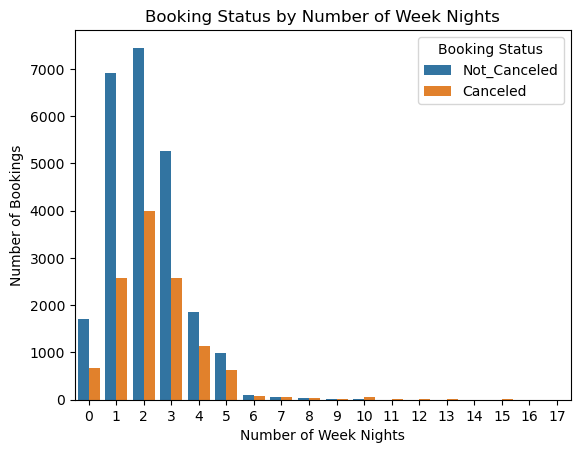

In [27]:
sns.countplot(x='no_of_week_nights', data=df, hue='booking_status')
plt.title('Booking Status by Number of Week Nights')  
plt.xlabel('Number of Week Nights')                   
plt.ylabel('Number of Bookings')                        
plt.legend(title='Booking Status')
plt.show()

1. The chart illustrates booking status distribution across different numbers of week nights.
2. Most bookings involve 1 to 3 week nights, with a clear dominance of not-canceled bookings.
3. Cancellations are relatively higher for stays with 2 or 3 week nights compared to other durations.
4. As the number of week nights increases beyond 4, both types of bookings decline sharply.
5. This indicates that shorter weekday stays are more common and have a slightly higher chance of cancellation.

In [28]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     27832
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64

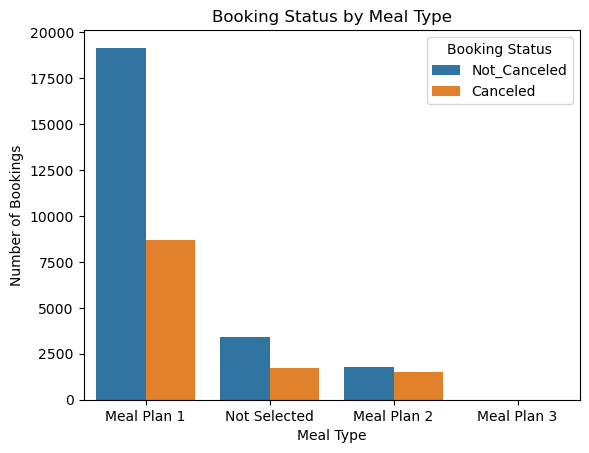

In [29]:
sns.countplot(x='type_of_meal_plan', data=df, hue='booking_status')
plt.title('Booking Status by Meal Type')      
plt.xlabel('Meal Type')                        
plt.ylabel('Number of Bookings')              
plt.legend(title='Booking Status')            
plt.show()

1. The chart displays booking status across different meal plan types.
2. Meal Plan 1 is the most popular choice, with a significantly higher number of not-canceled bookings.
3. Cancellations are also most frequent under Meal Plan 1 but still lower than successful bookings.
4. Very few customers choose Meal Plan 2 or 3, and their cancellation counts remain minimal.
5. Overall, Meal Plan 1 attracts the majority of guests, indicating it is the preferred and most reliable option.

In [30]:
df['required_car_parking_space'].value_counts()

required_car_parking_space
0    35148
1     1124
Name: count, dtype: int64

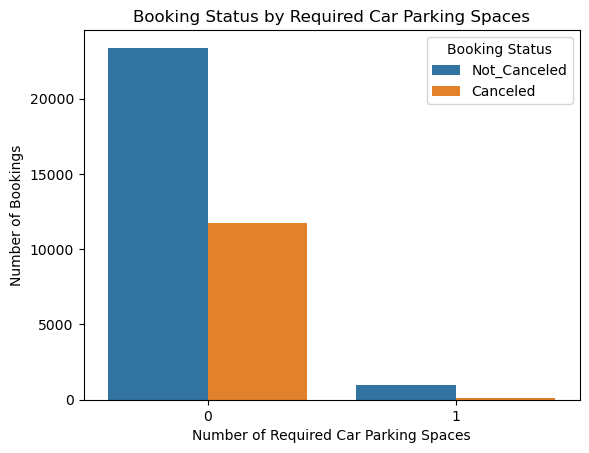

In [31]:
sns.countplot(x='required_car_parking_space', data=df, hue='booking_status')
plt.title('Booking Status by Required Car Parking Spaces')  
plt.xlabel('Number of Required Car Parking Spaces')         
plt.ylabel('Number of Bookings')                             
plt.legend(title='Booking Status')                           
plt.show()

In [32]:
df['room_type_reserved'].value_counts()

room_type_reserved
Room_Type 1    28129
Room_Type 4     6056
Room_Type 6      966
Room_Type 2      691
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

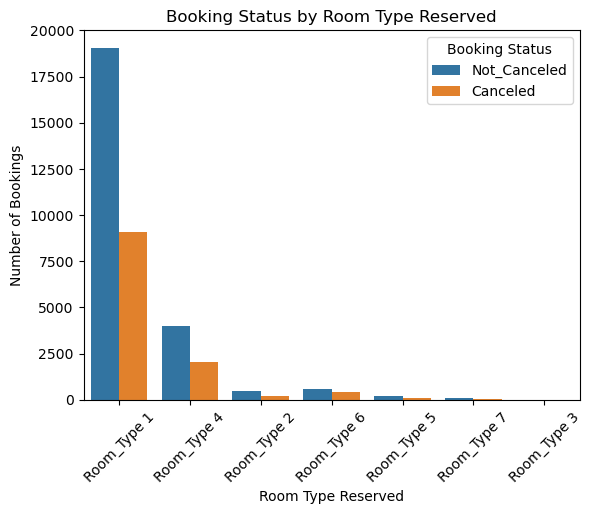

In [33]:
sns.countplot(x='room_type_reserved', data=df, hue='booking_status')
plt.title('Booking Status by Room Type Reserved')  
plt.xlabel('Room Type Reserved')                   
plt.ylabel('Number of Bookings')                 
plt.legend(title='Booking Status')                
plt.xticks(rotation=45)                         
plt.show()

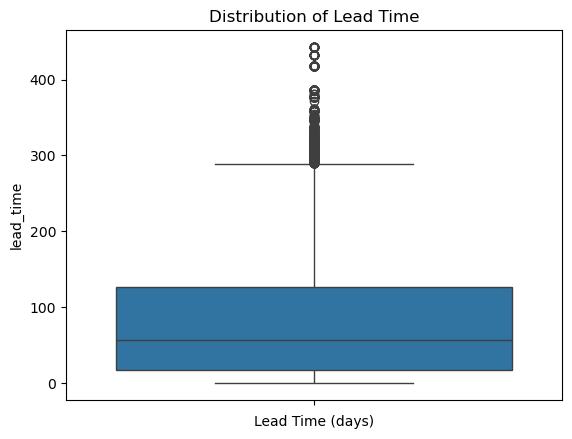

In [34]:
sns.boxplot(y=df['lead_time'])
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.show()

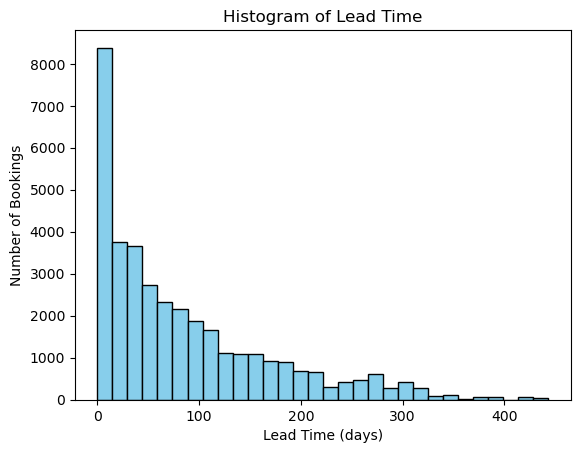

In [35]:
plt.hist(df['lead_time'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')
plt.show()

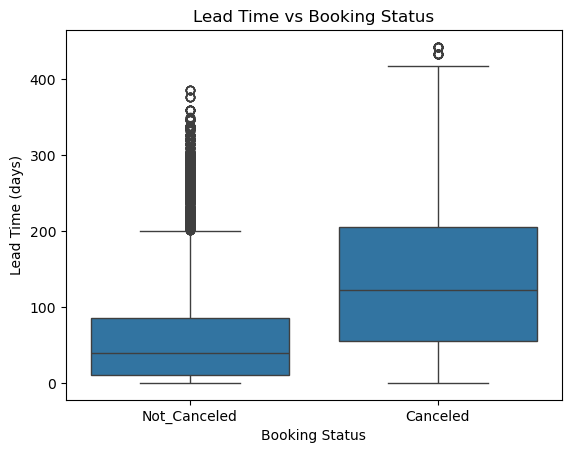

In [36]:
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title('Lead Time vs Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (days)')
plt.show()

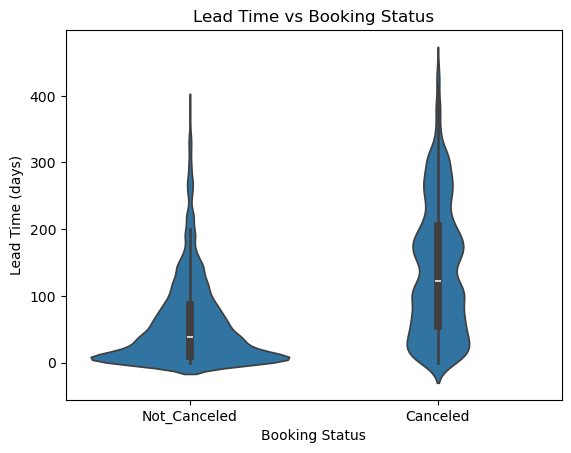

In [37]:
sns.violinplot(x='booking_status', y='lead_time', data=df)
plt.title('Lead Time vs Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (days)')
plt.show()

In [38]:
df['arrival_year'].value_counts()

arrival_year
2018    29760
2017     6512
Name: count, dtype: int64

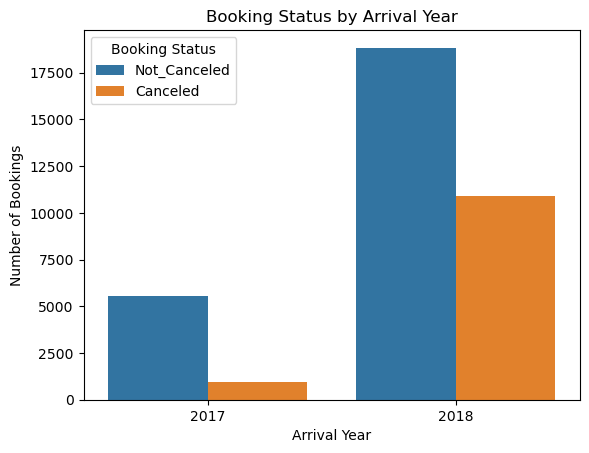

In [39]:
sns.countplot(x='arrival_year', data=df, hue='booking_status')
plt.title('Booking Status by Arrival Year')  
plt.xlabel('Arrival Year')                    
plt.ylabel('Number of Bookings')             
plt.legend(title='Booking Status')     
plt.show()

In [40]:
df['arrival_month'].value_counts()

arrival_month
10    5316
9     4611
8     3812
6     3203
12    3021
11    2980
7     2920
4     2736
5     2598
3     2358
2     1704
1     1013
Name: count, dtype: int64

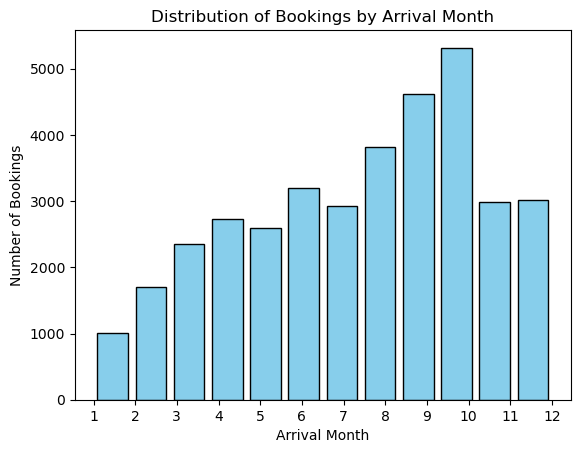

In [41]:
plt.hist(df['arrival_month'], bins=12, color='skyblue', edgecolor='black', rwidth=0.8)
plt.title('Distribution of Bookings by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')
plt.xticks(range(1, 13))  # Ensures x-axis shows all months from 1 to 12
plt.show()

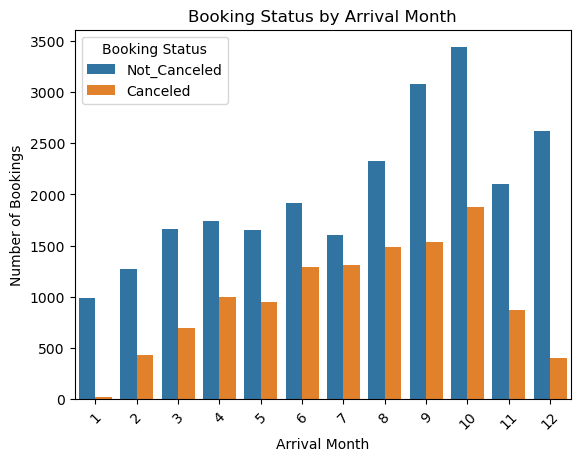

In [42]:
sns.countplot(x='arrival_month', data=df, hue='booking_status')
plt.title('Booking Status by Arrival Month')    
plt.xlabel('Arrival Month')                    
plt.ylabel('Number of Bookings')               
plt.legend(title='Booking Status')            
plt.xticks(rotation=45)      
plt.show()

In [43]:
df['arrival_date'].value_counts()

arrival_date
13    1357
17    1345
2     1331
4     1327
19    1327
16    1306
20    1281
15    1273
6     1273
18    1260
14    1242
30    1216
12    1203
8     1198
29    1190
21    1158
5     1154
26    1146
25    1146
1     1133
9     1130
28    1129
7     1110
24    1103
3     1098
11    1097
10    1089
27    1059
22    1023
23     990
31     578
Name: count, dtype: int64

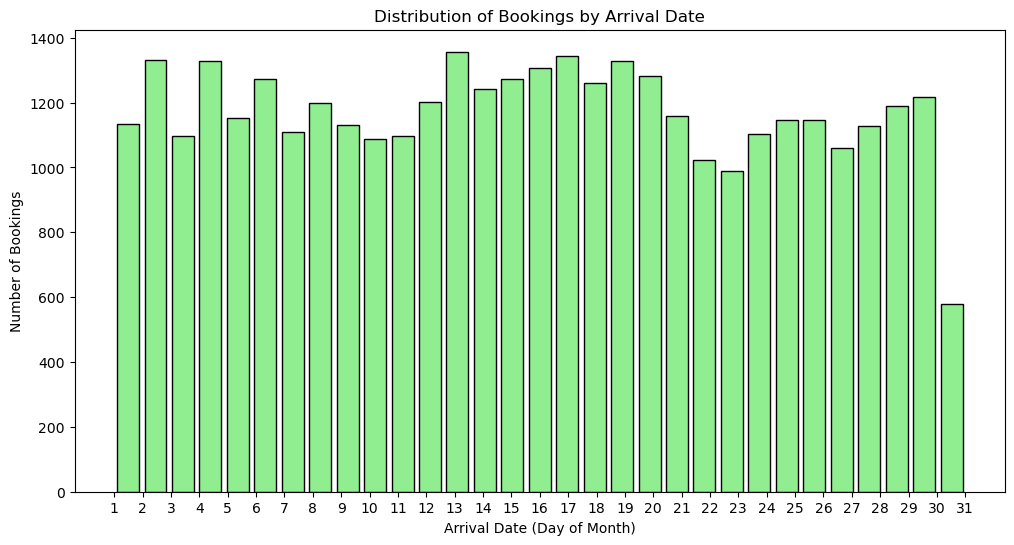

In [44]:
plt.figure(figsize=(12,6))
plt.hist(df['arrival_date'], bins=31, color='lightgreen', edgecolor='black', rwidth=0.8)
plt.title('Distribution of Bookings by Arrival Date')
plt.xlabel('Arrival Date (Day of Month)')
plt.ylabel('Number of Bookings')
plt.xticks(range(1, 32))  # Ensures x-axis shows all days from 1 to 31
plt.show()

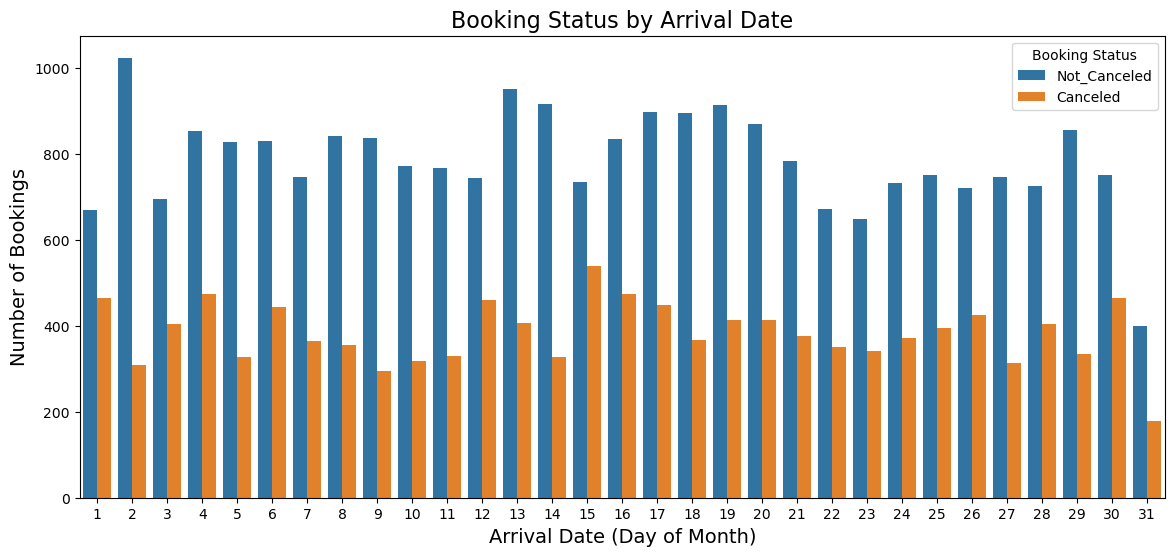

In [45]:
plt.figure(figsize=(14,6))  # Increase figure size for readability
sns.countplot(x='arrival_date', data=df, hue='booking_status')
plt.title('Booking Status by Arrival Date', fontsize=16)
plt.xlabel('Arrival Date (Day of Month)', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.legend(title='Booking Status')
plt.xticks(rotation=0)  # No rotation needed as days are short
plt.show()

In [46]:
df['market_segment_type'].value_counts()

market_segment_type
Online           23212
Offline          10528
Corporate         2016
Complementary      391
Aviation           125
Name: count, dtype: int64

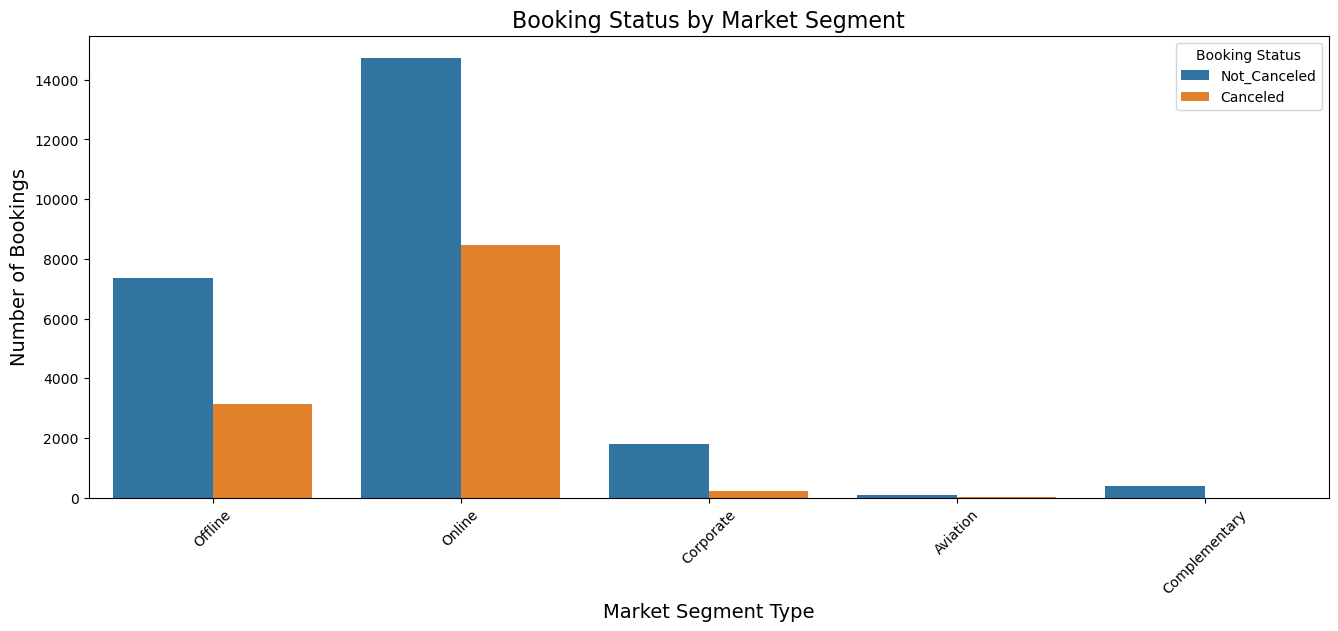

In [47]:
plt.figure(figsize=(16,6))  # Increase figure size for readability
sns.countplot(x='market_segment_type', data=df, hue='booking_status')
plt.title('Booking Status by Market Segment', fontsize=16)
plt.xlabel('Market Segment Type', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.legend(title='Booking Status')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()

1. The chart shows that most bookings come from the online and offline market segments.
2. Online bookings have a noticeably higher number of cancellations compared to offline ones.
3. Corporate, aviation, and complementary segments contribute relatively few bookings overall.
4. This indicates that online customers are more likely to cancel, while offline and corporate bookings tend to be more stable.

In [49]:
count = df[(df['market_segment_type'] == 'Aviation') & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

37


In [50]:
count = df[(df['market_segment_type'] == 'Complementary') & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

0


In [51]:
df['repeated_guest'].value_counts()

repeated_guest
0    35342
1      930
Name: count, dtype: int64

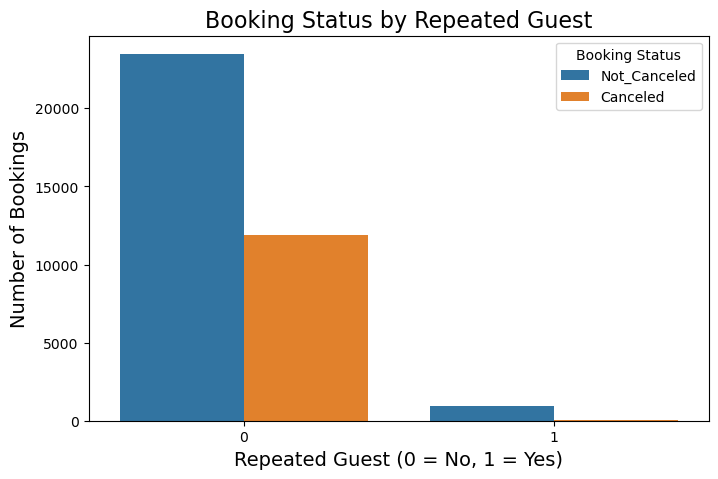

In [52]:
plt.figure(figsize=(8,5))  # Smaller figure since only two categories
sns.countplot(x='repeated_guest', data=df, hue='booking_status')
plt.title('Booking Status by Repeated Guest', fontsize=16)
plt.xlabel('Repeated Guest (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.legend(title='Booking Status')
plt.xticks(rotation=0)
plt.show()

1. The chart shows that most bookings are made by non-repeated guests (0).
2. Among them, cancellations are notably higher compared to repeated guests.
3. Repeated guests (1) have a much smaller share of total bookings and very few cancellations.
4. This suggests that loyal or returning customers are more consistent and less likely to cancel their bookings.

In [54]:
df['no_of_previous_cancellations'].value_counts()

no_of_previous_cancellations
0     35934
1       198
2        46
3        43
11       25
5        11
4        10
13        4
6         1
Name: count, dtype: int64

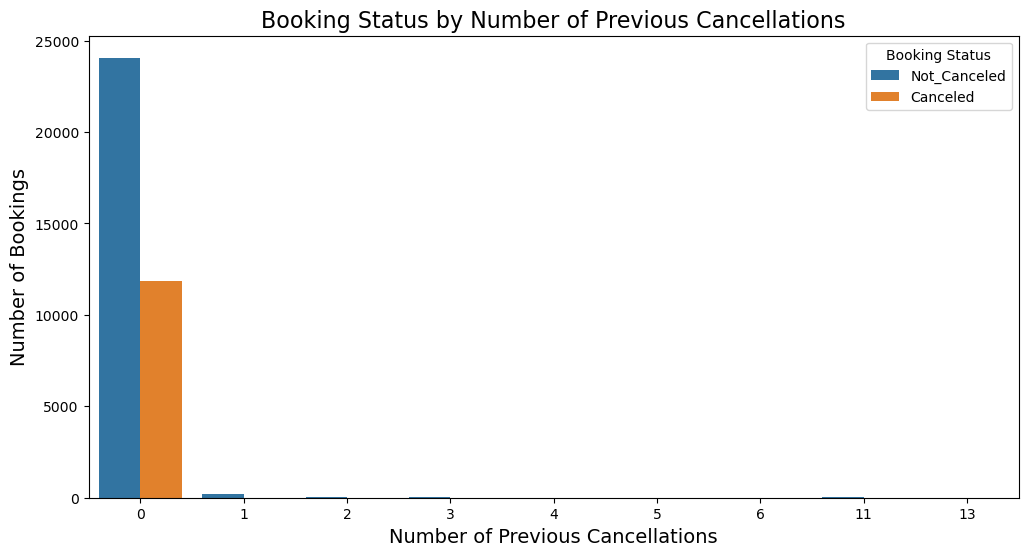

In [55]:
plt.figure(figsize=(12,6))  # Wider figure for multiple categories
sns.countplot(x='no_of_previous_cancellations', data=df, hue='booking_status')
plt.title('Booking Status by Number of Previous Cancellations', fontsize=16)
plt.xlabel('Number of Previous Cancellations', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.legend(title='Booking Status')
plt.xticks(rotation=0)  # No rotation needed for numeric categories
plt.show()

In [56]:
count = df[(df['no_of_previous_cancellations'] == 4) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

0


In [57]:
count = df[(df['no_of_previous_cancellations'] == 5) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

0


In [58]:
count = df[(df['no_of_previous_cancellations'] == 1) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

11


In [59]:
count = df[(df['no_of_previous_cancellations'] == 2) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

0


In [60]:
count = df[(df['no_of_previous_cancellations'] == 3) & (df['booking_status'] == 'Canceled')].shape[0]
print(count)

1


In [61]:
df['no_of_previous_bookings_not_canceled'].value_counts()

no_of_previous_bookings_not_canceled
0     35460
1       228
2       112
3        80
4        65
5        60
6        36
7        24
8        23
10       19
9        19
11       15
12       12
14        9
15        8
16        7
13        7
18        6
20        6
21        6
17        6
19        6
22        6
25        3
27        3
24        3
23        3
44        2
29        2
48        2
28        2
30        2
32        2
31        2
26        2
46        1
55        1
45        1
57        1
53        1
54        1
58        1
41        1
40        1
43        1
35        1
50        1
56        1
33        1
37        1
42        1
51        1
38        1
34        1
39        1
52        1
49        1
47        1
36        1
Name: count, dtype: int64

In [62]:
df['no_of_previous_bookings_not_canceled'].nunique()

59

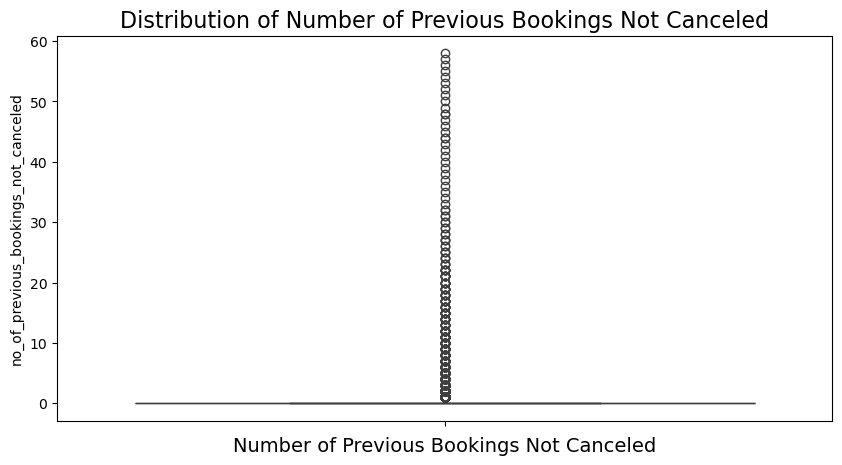

In [63]:
plt.figure(figsize=(10,5))
sns.boxplot(y=df['no_of_previous_bookings_not_canceled'])
plt.title('Distribution of Number of Previous Bookings Not Canceled', fontsize=16)
plt.xlabel('Number of Previous Bookings Not Canceled', fontsize=14)
plt.show()

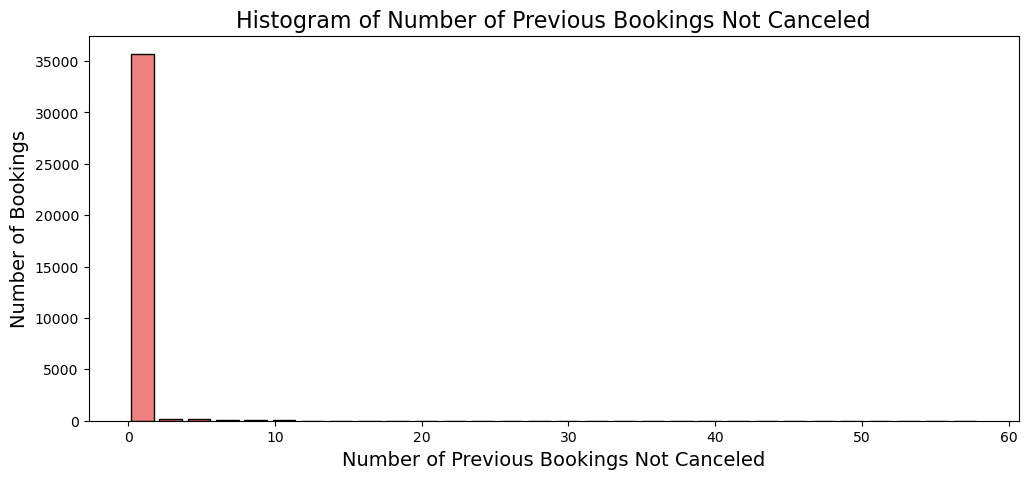

In [64]:
plt.figure(figsize=(12,5))
plt.hist(df['no_of_previous_bookings_not_canceled'], bins=30, color='lightcoral', edgecolor='black', rwidth=0.8)
plt.title('Histogram of Number of Previous Bookings Not Canceled', fontsize=16)
plt.xlabel('Number of Previous Bookings Not Canceled', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.show()

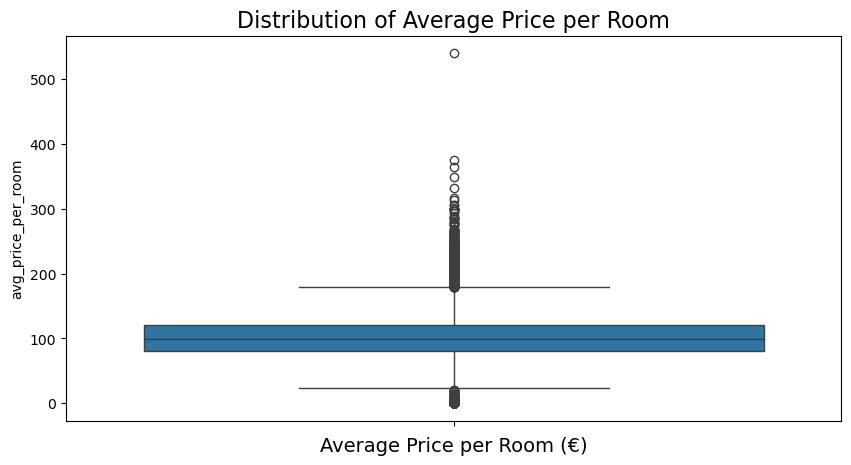

In [65]:
plt.figure(figsize=(10,5))
sns.boxplot(y=df['avg_price_per_room'])
plt.title('Distribution of Average Price per Room', fontsize=16)
plt.xlabel('Average Price per Room (€)', fontsize=14)
plt.show()

In [66]:
count_zero_price = df[df['avg_price_per_room'] == 0.0].shape[0]

print("Number of bookings with average price per room = 0:", count_zero_price)

Number of bookings with average price per room = 0: 545


In [67]:
median_per_year = df[df['avg_price_per_room'] > 0].groupby('arrival_year')['avg_price_per_room'].median()
print(median_per_year)

arrival_year
2017     90.00
2018    102.59
Name: avg_price_per_room, dtype: float64


In [68]:
def replace_zero_price(row):
    if row['avg_price_per_room'] == 0:
        return median_per_year[row['arrival_year']]
    else:
        return row['avg_price_per_room']

df['avg_price_per_room'] = df.apply(replace_zero_price, axis=1)

In [69]:
count_zero_price = df[df['avg_price_per_room'] == 0.0].shape[0]

print("Number of bookings with average price per room = 0:", count_zero_price)

Number of bookings with average price per room = 0: 0


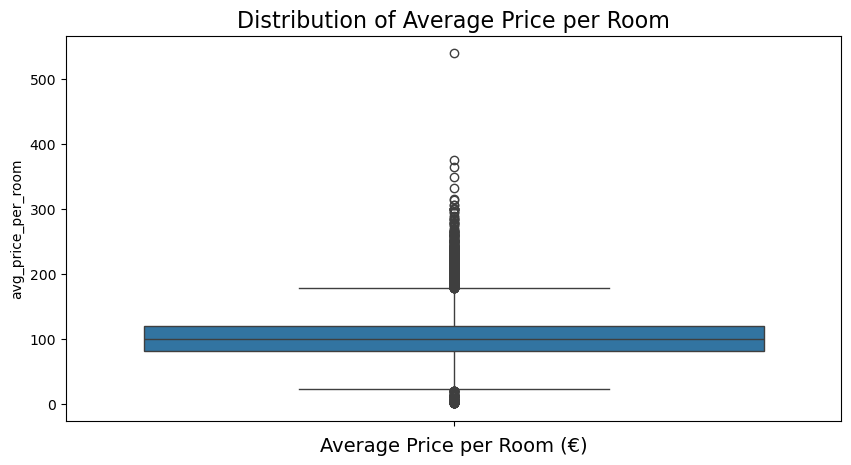

In [70]:
plt.figure(figsize=(10,5))
sns.boxplot(y=df['avg_price_per_room'])
plt.title('Distribution of Average Price per Room', fontsize=16)
plt.xlabel('Average Price per Room (€)', fontsize=14)
plt.show()

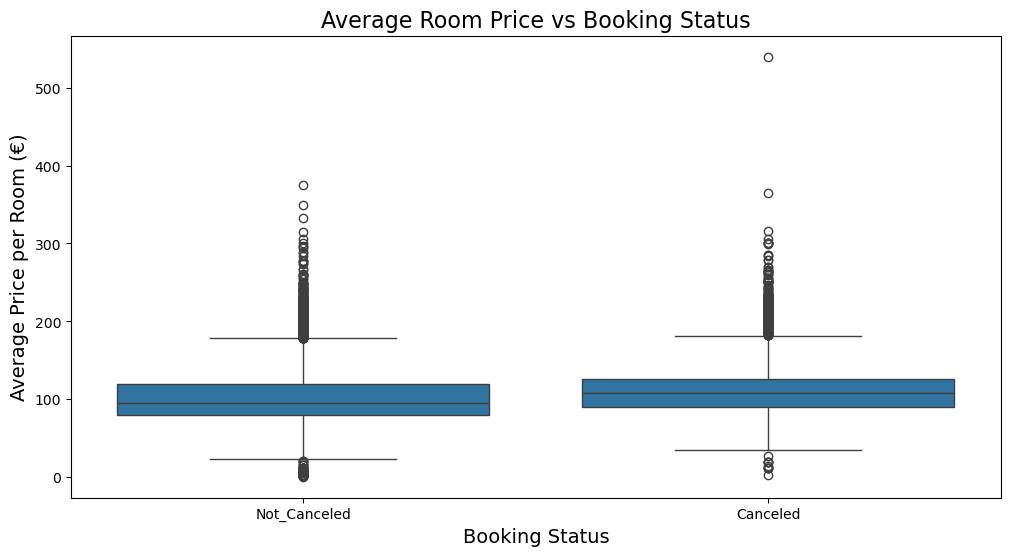

In [71]:
plt.figure(figsize=(12,6))
sns.boxplot(x='booking_status', y='avg_price_per_room', data=df)
plt.title('Average Room Price vs Booking Status', fontsize=16)
plt.xlabel('Booking Status', fontsize=14)
plt.ylabel('Average Price per Room (€)', fontsize=14)
plt.show()

1. The boxplot shows that the average room price is slightly higher for canceled bookings compared to non-canceled ones.
2. Both groups have similar interquartile ranges, indicating comparable price variability.
3. However, canceled bookings show more extreme outliers, suggesting that very high-priced rooms are more likely to be canceled.
4. This implies that price sensitivity might influence customers’ cancellation behavior.

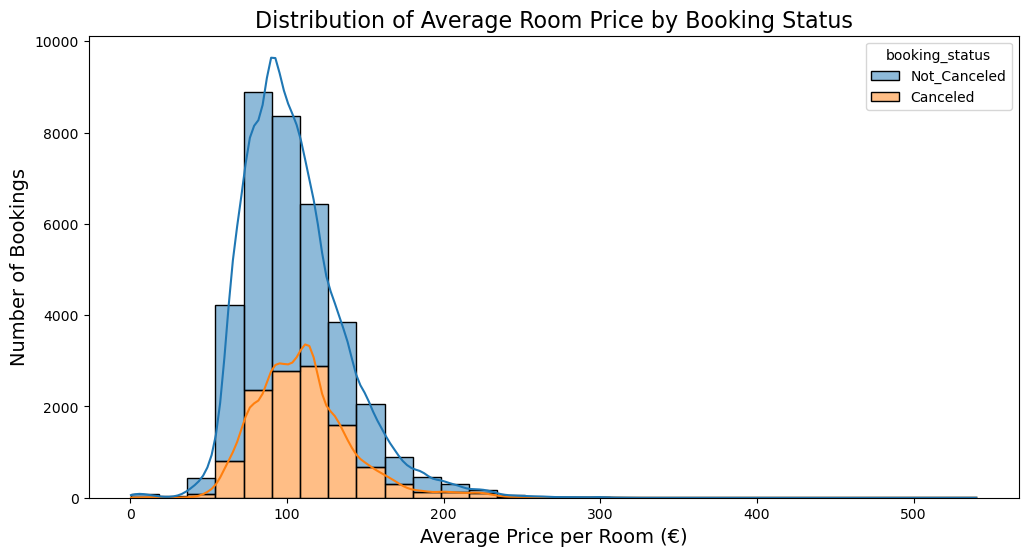

In [73]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='avg_price_per_room', hue='booking_status', bins=30, kde=True, multiple='stack')
plt.title('Distribution of Average Room Price by Booking Status', fontsize=16)
plt.xlabel('Average Price per Room (€)', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.show()

1. Most bookings, whether canceled or not, are concentrated in the €50–150 range.
2. Not canceled bookings dominate across all price ranges, indicating most customers follow through with their reservations.
3. Canceled bookings are fewer but follow a similar distribution, slightly more common in the mid-price range (€80–120).
4. The distribution is right-skewed, with very few bookings at very high prices (>€300).
5. This suggests that average room price may influence cancellation slightly, but other factors likely play a larger role.

In [75]:
df['no_of_special_requests'].value_counts()

no_of_special_requests
0    19776
1    11371
2     4364
3      675
4       78
5        8
Name: count, dtype: int64

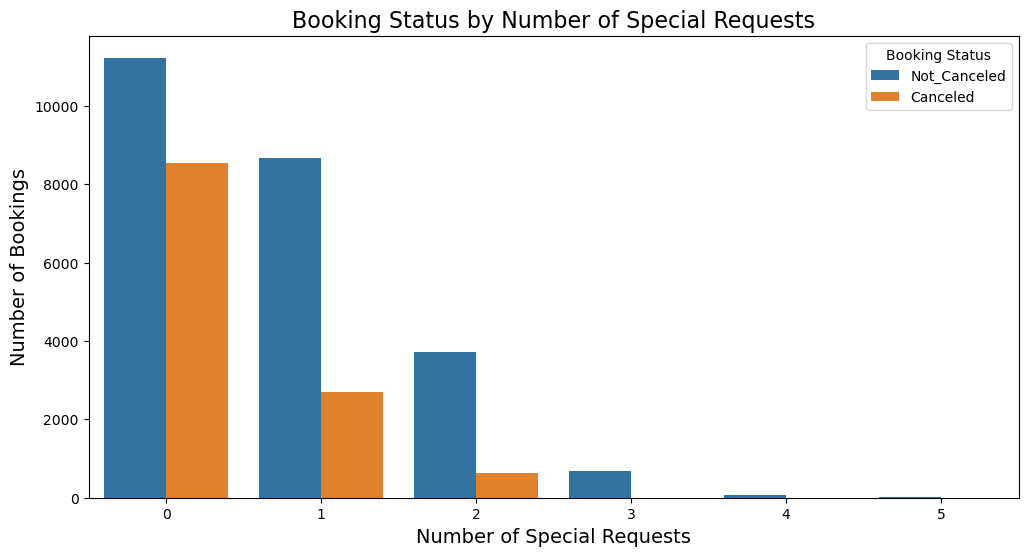

In [76]:
plt.figure(figsize=(12,6))  # Wider figure for multiple categories
sns.countplot(x='no_of_special_requests', data=df, hue='booking_status')
plt.title('Booking Status by Number of Special Requests', fontsize=16)
plt.xlabel('Number of Special Requests', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.legend(title='Booking Status')
plt.xticks(rotation=0)  # No rotation needed for numeric categories
plt.show()

1. Most bookings have 0 or 1 special requests, with the number of bookings decreasing sharply as requests increase.
2. Not_Canceled bookings dominate across all levels of special requests, especially when requests are 0 or 1.
3. Canceled bookings are comparatively fewer, but the proportion of cancellations seems higher when there are more special requests.
4. Very few bookings have 4 or 5 special requests, indicating that high special request counts are rare.
5. Overall, the plot shows that the number of special requests is inversely related to booking frequency, and cancellations are more likely with increasing special requests.

In [78]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    24388
Canceled        11884
Name: count, dtype: int64

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36272 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36272 non-null  object 
 1   no_of_adults                          36272 non-null  int64  
 2   no_of_children                        36272 non-null  int64  
 3   no_of_weekend_nights                  36272 non-null  int64  
 4   no_of_week_nights                     36272 non-null  int64  
 5   type_of_meal_plan                     36272 non-null  object 
 6   required_car_parking_space            36272 non-null  int64  
 7   room_type_reserved                    36272 non-null  object 
 8   lead_time                             36272 non-null  int64  
 9   arrival_year                          36272 non-null  int64  
 10  arrival_month                         36272 non-null  int64  
 11  arrival_date        

In [80]:
# Combine year, month, day into datetime, invalid days become last day of the month
df['arrival_date_full'] = pd.to_datetime(
    df['arrival_year'].astype(str) + '-' +
    df['arrival_month'].astype(str) + '-' +
    df['arrival_date'].astype(str),
    errors='coerce'
)

# Replace invalid dates (NaT) with last day of that month
df['arrival_date_full'] = df['arrival_date_full'].fillna(
    pd.to_datetime(df['arrival_year'].astype(str) + '-' +
                   df['arrival_month'].astype(str)) + MonthEnd(0)
)

# Sort the dataframe by arrival_date_full in ascending order
df.sort_values(by='arrival_date_full', ascending=True, inplace=True)

# Reset index if you want a clean index after sorting
df.reset_index(drop=True, inplace=True)

In [81]:
df['arrival_date_full'].head()

0   2017-07-01
1   2017-07-01
2   2017-07-01
3   2017-07-01
4   2017-07-01
Name: arrival_date_full, dtype: datetime64[ns]

In [82]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_date_full
0,INN31969,1,0,0,2,Meal Plan 2,0,Room_Type 1,257,2017,7,1,Offline,0,0,0,80.0,0,Not_Canceled,2017-07-01
1,INN03899,2,0,0,2,Meal Plan 2,0,Room_Type 1,257,2017,7,1,Online,0,0,0,101.5,0,Canceled,2017-07-01
2,INN01776,1,0,0,4,Meal Plan 1,0,Room_Type 1,65,2017,7,1,Online,0,0,0,68.0,1,Canceled,2017-07-01
3,INN14890,2,0,0,2,Meal Plan 2,0,Room_Type 1,257,2017,7,1,Offline,0,0,0,101.5,0,Canceled,2017-07-01
4,INN07680,2,0,0,2,Meal Plan 2,0,Room_Type 1,257,2017,7,1,Offline,0,0,0,101.5,0,Canceled,2017-07-01


In [83]:
df.drop(columns=['Booking_ID', 'arrival_year', 'arrival_month', 'arrival_date'], inplace=True)

In [84]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_date_full
0,1,0,0,2,Meal Plan 2,0,Room_Type 1,257,Offline,0,0,0,80.0,0,Not_Canceled,2017-07-01
1,2,0,0,2,Meal Plan 2,0,Room_Type 1,257,Online,0,0,0,101.5,0,Canceled,2017-07-01
2,1,0,0,4,Meal Plan 1,0,Room_Type 1,65,Online,0,0,0,68.0,1,Canceled,2017-07-01
3,2,0,0,2,Meal Plan 2,0,Room_Type 1,257,Offline,0,0,0,101.5,0,Canceled,2017-07-01
4,2,0,0,2,Meal Plan 2,0,Room_Type 1,257,Offline,0,0,0,101.5,0,Canceled,2017-07-01


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36272 entries, 0 to 36271
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          36272 non-null  int64         
 1   no_of_children                        36272 non-null  int64         
 2   no_of_weekend_nights                  36272 non-null  int64         
 3   no_of_week_nights                     36272 non-null  int64         
 4   type_of_meal_plan                     36272 non-null  object        
 5   required_car_parking_space            36272 non-null  int64         
 6   room_type_reserved                    36272 non-null  object        
 7   lead_time                             36272 non-null  int64         
 8   market_segment_type                   36272 non-null  object        
 9   repeated_guest                        36272 non-null  int64         
 10

In [86]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude specific columns
exclude_cols = ['required_car_parking_space', 'repeated_guest']
cols_to_scale = [col for col in numeric_cols if col not in exclude_cols]

# Initialize scaler
scaler = StandardScaler()

# Scale the selected columns
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [87]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_date_full
0,-1.629000,-0.265409,-0.931161,-0.144779,Meal Plan 2,0,Room_Type 1,1.998836,Offline,0,-0.063396,-0.08746,-0.760913,-0.788114,Not_Canceled,2017-07-01
1,0.298864,-0.265409,-0.931161,-0.144779,Meal Plan 2,0,Room_Type 1,1.998836,Online,0,-0.063396,-0.08746,-0.103520,-0.788114,Canceled,2017-07-01
2,-1.629000,-0.265409,-0.931161,1.272803,Meal Plan 1,0,Room_Type 1,-0.235515,Online,0,-0.063396,-0.08746,-1.127831,0.483753,Canceled,2017-07-01
3,0.298864,-0.265409,-0.931161,-0.144779,Meal Plan 2,0,Room_Type 1,1.998836,Offline,0,-0.063396,-0.08746,-0.103520,-0.788114,Canceled,2017-07-01
4,0.298864,-0.265409,-0.931161,-0.144779,Meal Plan 2,0,Room_Type 1,1.998836,Offline,0,-0.063396,-0.08746,-0.103520,-0.788114,Canceled,2017-07-01


In [88]:
df['booking_status'] = df['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})

In [89]:
df['booking_status'].head()

0    0
1    1
2    1
3    1
4    1
Name: booking_status, dtype: int64

In [90]:
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

# One-hot encode the selected columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

onehot_cols = [col for col in df.columns if any(c in col for c in categorical_cols)]
df[onehot_cols] = df[onehot_cols].astype(int)

# Check the result
df[onehot_cols].head()

,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0


In [91]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,-1.629000,-0.265409,-0.931161,-0.144779,0,1.998836,0,-0.063396,-0.08746,-0.760913,...,0,0,0,0,0,0,0,0,1,0
1,0.298864,-0.265409,-0.931161,-0.144779,0,1.998836,0,-0.063396,-0.08746,-0.103520,...,0,0,0,0,0,0,0,0,0,1
2,-1.629000,-0.265409,-0.931161,1.272803,0,-0.235515,0,-0.063396,-0.08746,-1.127831,...,0,0,0,0,0,0,0,0,0,1
3,0.298864,-0.265409,-0.931161,-0.144779,0,1.998836,0,-0.063396,-0.08746,-0.103520,...,0,0,0,0,0,0,0,0,1,0
4,0.298864,-0.265409,-0.931161,-0.144779,0,1.998836,0,-0.063396,-0.08746,-0.103520,...,0,0,0,0,0,0,0,0,1,0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36272 entries, 0 to 36271
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          36272 non-null  float64       
 1   no_of_children                        36272 non-null  float64       
 2   no_of_weekend_nights                  36272 non-null  float64       
 3   no_of_week_nights                     36272 non-null  float64       
 4   required_car_parking_space            36272 non-null  int64         
 5   lead_time                             36272 non-null  float64       
 6   repeated_guest                        36272 non-null  int64         
 7   no_of_previous_cancellations          36272 non-null  float64       
 8   no_of_previous_bookings_not_canceled  36272 non-null  float64       
 9   avg_price_per_room                    36272 non-null  float64       
 10

In [93]:
df_random = df.copy()

In [94]:
tscv = TimeSeriesSplit(n_splits=5)

X = df.drop(columns=['booking_status', 'arrival_date_full'])  # Features
y = df['booking_status']  # Target

# Models With TimeSeriesSplit

## Logistic Regression

In [96]:
# Lists to store metrics
precision_list = []
recall_list = []
f1_list = []
support_list = []
accuracy_list = []

# Loop through each split
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train model
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store metrics
    precision_list.append([report['0']['precision'], report['1']['precision']])
    recall_list.append([report['0']['recall'], report['1']['recall']])
    f1_list.append([report['0']['f1-score'], report['1']['f1-score']])
    support_list.append([report['0']['support'], report['1']['support']])
    accuracy_list.append(report['accuracy'])

# Compute mean metrics
mean_precision = np.mean(precision_list, axis=0)
mean_recall = np.mean(recall_list, axis=0)
mean_f1 = np.mean(f1_list, axis=0)
mean_support = np.mean(support_list, axis=0).astype(int)
mean_accuracy = np.mean(accuracy_list)

# Create final dataframe similar to classification_report
final_report = pd.DataFrame({
    'precision': mean_precision,
    'recall': mean_recall,
    'f1-score': mean_f1,
    'support': mean_support
}, index=['Class 0', 'Class 1'])

# Add overall accuracy row
final_report.loc['accuracy'] = [mean_accuracy, mean_accuracy, mean_accuracy, mean_support.sum()]

# Display final table
print(final_report)

          precision    recall  f1-score  support
Class 0    0.865003  0.699112  0.769198   3858.0
Class 1    0.582577  0.761732  0.657627   2186.0
accuracy   0.738726  0.738726  0.738726   6044.0


## Random Forest

In [98]:
# Hyperparameters for Random Forest
param_grid = {
    'n_estimators': [100, 200],          # Number of trees
    'max_depth': [5, 10, None],          # Max depth of trees
    'min_samples_split': [2, 5],         # Minimum samples to split a node
    'min_samples_leaf': [1, 2],          # Minimum samples at a leaf node
    'class_weight': ['balanced']         # Handle imbalance
}

# Lists to store metrics for each fold
precision_list = []
recall_list = []
f1_list = []
support_list = []
accuracy_list = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize Random Forest
    rf = RandomForestClassifier(random_state=42)
    
    # Grid search with CV within the training fold
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=3,                     # internal CV for hyperparameter tuning
        scoring='f1',             # focus on F1-score for minority class
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Best model from GridSearch
    best_model = grid_search.best_estimator_
    
    # Predict on test fold
    y_pred = best_model.predict(X_test)
    
    # Classification report for this fold
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store metrics for both classes
    precision_list.append([report['0']['precision'], report['1']['precision']])
    recall_list.append([report['0']['recall'], report['1']['recall']])
    f1_list.append([report['0']['f1-score'], report['1']['f1-score']])
    support_list.append([report['0']['support'], report['1']['support']])
    accuracy_list.append(report['accuracy'])

# Compute mean metrics across all folds
mean_precision = np.mean(precision_list, axis=0)
mean_recall = np.mean(recall_list, axis=0)
mean_f1 = np.mean(f1_list, axis=0)
mean_support = np.mean(support_list, axis=0).astype(int)
mean_accuracy = np.mean(accuracy_list)

# Final report in tabular format
final_report = pd.DataFrame({
    'precision': mean_precision,
    'recall': mean_recall,
    'f1-score': mean_f1,
    'support': mean_support
}, index=['Class 0', 'Class 1'])

# Add overall accuracy row
final_report.loc['accuracy'] = [mean_accuracy, mean_accuracy, mean_accuracy, mean_support.sum()]

# Display final table
print(final_report)

          precision    recall  f1-score  support
Class 0    0.841156  0.773899  0.803488   3858.0
Class 1    0.609582  0.679650  0.638309   2186.0
accuracy   0.761820  0.761820  0.761820   6044.0


## XGBoost

In [100]:
param_grid = {
    'n_estimators': [100, 200],           # Number of trees
    'max_depth': [3, 5, 7],                 # Max depth of trees
    'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinkage
    'min_child_weight': [1, 3, 5],             # Minimum sum of instance weight needed in a child
    'gamma': [0.1, 0.3],                    # Minimum loss reduction required to make a split
}
# Lists to store metrics
precision_list = []
recall_list = []
f1_list = []
support_list = []
accuracy_list = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize XGBoost classifier
    xgb = XGBClassifier(eval_metric='logloss', random_state=42)
    
    # Grid search with CV inside training fold
    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=3,
        scoring='f1',   # optimize for minority class
    )
    
    grid_search.fit(X_train, y_train)
    
    # Best model from GridSearch
    best_model = grid_search.best_estimator_
    
    # Predict on test fold
    y_pred = best_model.predict(X_test)
    
    # Classification report for this fold
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store metrics for both classes
    precision_list.append([report['0']['precision'], report['1']['precision']])
    recall_list.append([report['0']['recall'], report['1']['recall']])
    f1_list.append([report['0']['f1-score'], report['1']['f1-score']])
    support_list.append([report['0']['support'], report['1']['support']])
    accuracy_list.append(report['accuracy'])

# Compute mean metrics across all folds
mean_precision = np.mean(precision_list, axis=0)
mean_recall = np.mean(recall_list, axis=0)
mean_f1 = np.mean(f1_list, axis=0)
mean_support = np.mean(support_list, axis=0).astype(int)
mean_accuracy = np.mean(accuracy_list)

# Final report table
final_report = pd.DataFrame({
    'precision': mean_precision,
    'recall': mean_recall,
    'f1-score': mean_f1,
    'support': mean_support
}, index=['Class 0', 'Class 1'])

# Add overall accuracy row
final_report.loc['accuracy'] = [mean_accuracy, mean_accuracy, mean_accuracy, mean_support.sum()]

# Display final table
print(final_report)

          precision    recall  f1-score  support
Class 0    0.813617  0.905883  0.856308   3858.0
Class 1    0.721633  0.566882  0.619230   2186.0
accuracy   0.804996  0.804996  0.804996   6044.0


## Decision Tree

In [102]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Lists to store metrics
precision_list = []
recall_list = []
f1_list = []
support_list = []
accuracy_list = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize Decision Tree
    dt = DecisionTreeClassifier(random_state=42)
    
    # Grid search inside each fold
    grid_search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=3,
        scoring='f1',  # optimize for minority class
    )
    
    grid_search.fit(X_train, y_train)
    
    # Best model from GridSearch
    best_model = grid_search.best_estimator_
    
    # Predict on test fold
    y_pred = best_model.predict(X_test)
    
    # Classification report for this fold
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store metrics
    precision_list.append([report['0']['precision'], report['1']['precision']])
    recall_list.append([report['0']['recall'], report['1']['recall']])
    f1_list.append([report['0']['f1-score'], report['1']['f1-score']])
    support_list.append([report['0']['support'], report['1']['support']])
    accuracy_list.append(report['accuracy'])

# Compute mean metrics across all folds
mean_precision = np.mean(precision_list, axis=0)
mean_recall = np.mean(recall_list, axis=0)
mean_f1 = np.mean(f1_list, axis=0)
mean_support = np.mean(support_list, axis=0).astype(int)
mean_accuracy = np.mean(accuracy_list)

# Final report table
final_report = pd.DataFrame({
    'precision': mean_precision,
    'recall': mean_recall,
    'f1-score': mean_f1,
    'support': mean_support
}, index=['Class 0', 'Class 1'])

# Add overall accuracy row
final_report.loc['accuracy'] = [mean_accuracy, mean_accuracy, mean_accuracy, mean_support.sum()]

# Display final table
print(final_report)

          precision    recall  f1-score  support
Class 0    0.820438  0.874258  0.845958   3858.0
Class 1    0.691645  0.610559  0.645082   2186.0
accuracy   0.795170  0.795170  0.795170   6044.0


# Models With Random Split

In [104]:
x_rand = df_random.drop(columns=['booking_status', 'arrival_date_full'])
y_rand = df_random['booking_status']

In [105]:
x_train_rand, x_test_rand, y_train_rand, y_test_rand = train_test_split(
    x_rand, y_rand, test_size=0.2, random_state=42, stratify=y_rand
)

In [106]:
y_train_rand.value_counts()

booking_status
0    19510
1     9507
Name: count, dtype: int64

In [107]:
ros = RandomOverSampler(random_state=42)
x_train_res, y_train_res = ros.fit_resample(x_train_rand, y_train_rand)

print("Before:", y_train_rand.value_counts(normalize=True) * 100)
print("After:", y_train_res.value_counts(normalize=True) * 100)

Before: booking_status
0    67.236448
1    32.763552
Name: proportion, dtype: float64
After: booking_status
0    50.0
1    50.0
Name: proportion, dtype: float64


In [108]:
y_train_res.value_counts()

booking_status
0    19510
1    19510
Name: count, dtype: int64

## Logistic Regression

In [110]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg.fit(x_train_res, y_train_res)

# Predict on the (original) test set
y_pred = log_reg.predict(x_test_rand)

print("\nClassification Report:\n", classification_report(y_test_rand, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      4878
           1       0.64      0.77      0.70      2377

    accuracy                           0.78      7255
   macro avg       0.76      0.78      0.77      7255
weighted avg       0.80      0.78      0.79      7255



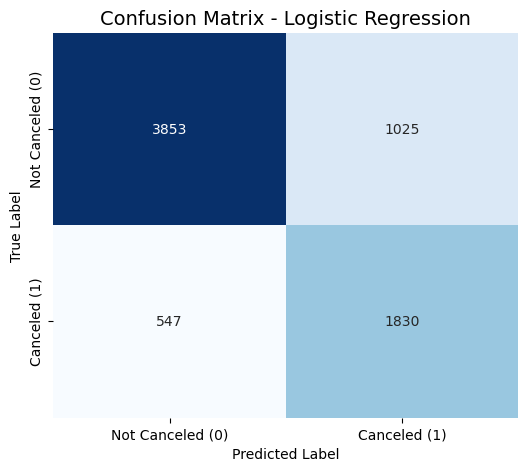

In [111]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_rand, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not Canceled (0)', 'Canceled (1)'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Decision Tree

In [113]:
# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Set up hyperparameter grid
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           cv=5, scoring='accuracy')

# Train the model on resampled training datakm55
grid_search.fit(x_train_res, y_train_res)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Predict on the original test set
y_pred_dt = grid_search.predict(x_test_rand)

# Classification report
print("\nClassification Report for Decision Tree:\n", classification_report(y_test_rand, y_pred_dt))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      4878
           1       0.78      0.79      0.78      2377

    accuracy                           0.86      7255
   macro avg       0.84      0.84      0.84      7255
weighted avg       0.86      0.86      0.86      7255



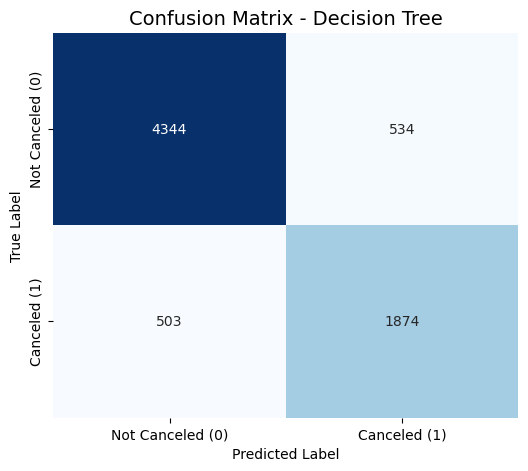

In [114]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_rand, y_pred_dt), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not Canceled (0)', 'Canceled (1)'])
plt.title('Confusion Matrix - Decision Tree', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Random Forest

In [116]:
# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees
    'max_depth': [10, 20, 30],       # Maximum depth of tree
    'min_samples_split': [2, 5, 10],       # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],         # Minimum samples at leaf node
    # 'max_features': ['auto', 'sqrt', 'log2']  # Number of features to consider at each split
}

# GridSearchCV setup
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=5, scoring='accuracy',)

# Train on resampled training data
grid_search_rf.fit(x_train_res, y_train_res)

# Best parameters
print("Best Parameters:", grid_search_rf.best_params_)

# Predict on the original test set
y_pred_rf = grid_search_rf.predict(x_test_rand)

# Classification report
print("\nClassification Report for Random Forest:\n", classification_report(y_test_rand, y_pred_rf))


Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91      4878
           1       0.83      0.81      0.82      2377

    accuracy                           0.88      7255
   macro avg       0.87      0.86      0.87      7255
weighted avg       0.88      0.88      0.88      7255



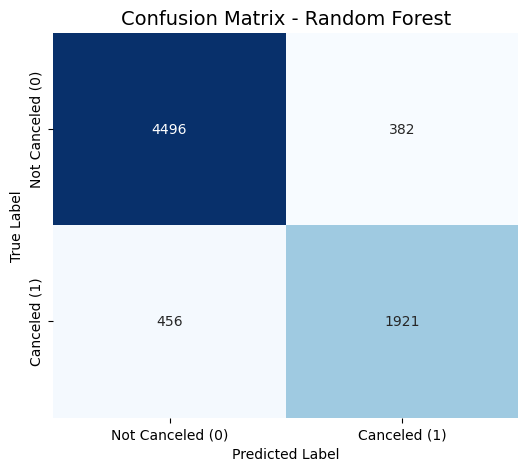

In [117]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_rand, y_pred_rf), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not Canceled (0)', 'Canceled (1)'])
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## XGBoost

In [119]:
# Initialize XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight' :[3,5,7],
}

# GridSearchCV setup
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid,
                               cv=5, scoring='accuracy')

# Train on resampled training data
grid_search_xgb.fit(x_train_res, y_train_res)

# Best parameters
print("Best Parameters:", grid_search_xgb.best_params_)

# Predict on the original test set
y_pred_xgb = grid_search_xgb.predict(x_test_rand)

# Classification report
print("\nClassification Report for XGBoost:\n", classification_report(y_test_rand, y_pred_xgb))



C:\Users\Deep\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'learning_rate': 0.2, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 300}

Classification Report for XGBoost:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      4878
           1       0.81      0.82      0.82      2377

    accuracy                           0.88      7255
   macro avg       0.86      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



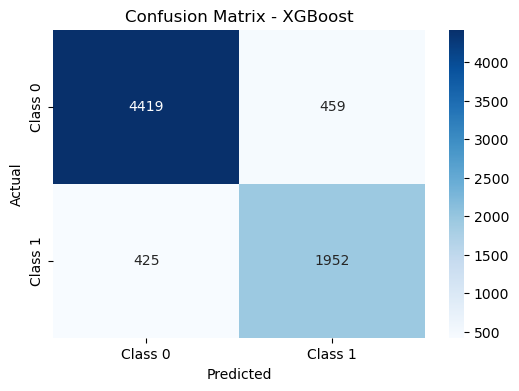

In [120]:
# Confusion Matrix
cm = confusion_matrix(y_test_rand, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0','Class 1'], yticklabels=['Class 0','Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## Conclusion

1. In the TimeSeries Split, XGBoost achieved the highest accuracy (≈80.5%), followed by Decision Tree (≈79.5%), while Logistic Regression and Random Forest performed moderately around 74–76%.
2. These results suggest that tree-based models handled temporal data better, capturing non-linear booking trends over time.
3. In the Random Split, all models performed significantly better, with Random Forest and XGBoost both achieving ≈88% accuracy and strong precision–recall balance.
4. Decision Tree and Logistic Regression also performed well (≈86% and ≈78% accuracy respectively), but ensemble models clearly delivered superior generalization.
5. The performance difference between the two splits indicates that the models are sensitive to temporal patterns—suggesting future forecasting should prefer time-aware validation.
6. Overall, using XGBoost or Random Forest aligns best with the company’s aim to improve revenue management, optimize resource allocation, and enable targeted retention strategies, as these models provide robust and reliable booking status predictions.